In [ ]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os


In [ ]:
# Load the dataset
cwd = os.getcwd()
df = pd.read_csv(cwd+"/benin-malanville.csv", parse_dates=['Timestamp'])
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [ ]:
# Descriptive stats for numeric columns
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-02-07 12:00:30.000000512,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
min,2021-08-09 00:01:00,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,2021-11-08 06:00:45,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,2022-02-07 12:00:30,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,2022-05-09 18:00:15,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,2022-08-09 00:00:00,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN
std,NaN,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN


In [ ]:
# Count missing values
df.isna().sum()

,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0
WSgust,0


In [ ]:
# Identify columns with more than 5% missing values (which there is none)
missing_percent = df.isna().mean() * 100
print("\n🔍 Columns with >5% missing values:")
print(missing_percent[missing_percent > 5])


🔍 Columns with >5% missing values:
Comments    100.0
dtype: float64


In [ ]:
# 3. Outlier Detection & Basic Cleaning
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Fill missing values with median for selected columns
df[key_cols] = df[key_cols].apply(lambda col: col.fillna(col.median()))

In [ ]:
# Compute Z-scores for outlier detection
z_scores = df[key_cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_rows = outliers.any(axis=1)
print(f"\ Outliers Detected: {outlier_rows.sum()} rows")


🚨 Outliers Detected: 7740 rows


In [ ]:
df.shape

(525600, 19)

In [ ]:
# Drop rows with outliers
df_clean = df[~outlier_rows].copy()

In [ ]:
os.makedirs("/content/data", exist_ok=True)

In [ ]:
# save the cleaned CSV
df_clean.to_csv("/content/data/benin_clean.csv", index=False)
print("✅ Cleaned data saved to /content/data/benin_clean.csv")

✅ Cleaned data saved to /content/data/benin_clean.csv


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


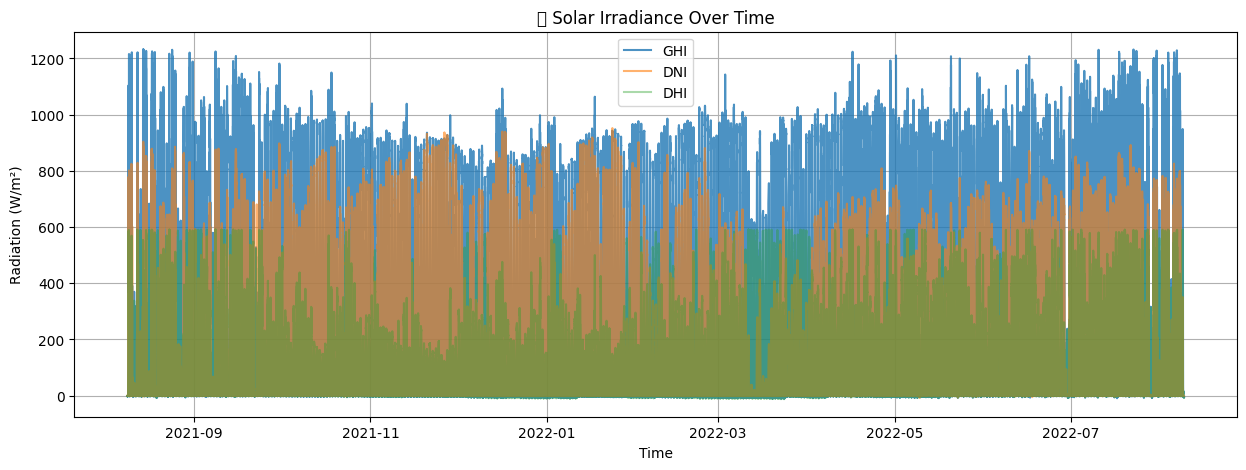

In [ ]:
#  4. Time Series Analysis
# Visualize solar patterns and detect temporal trends

plt.figure(figsize=(15, 5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI', alpha=0.8)
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI', alpha=0.6)
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI', alpha=0.4)
plt.xlabel("Time")
plt.ylabel("Radiation (W/m²)")
plt.title("📅 Solar Irradiance Over Time")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


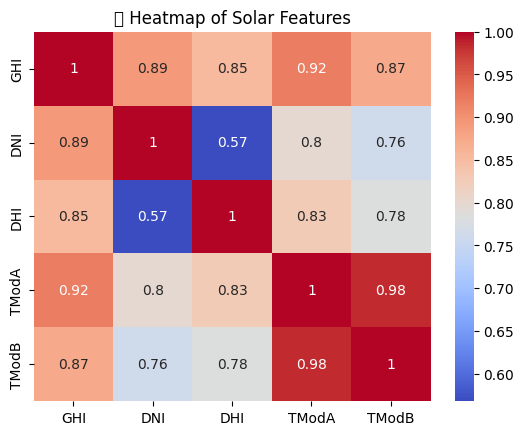

In [ ]:
#  6. Correlation & Relationship Analysis
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("📊 Heatmap of Solar Features")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


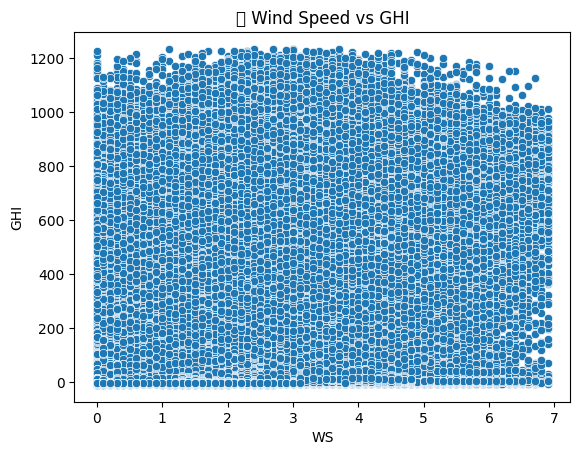

In [ ]:
# Scatter plot examples
sns.scatterplot(data=df_clean, x='WS', y='GHI')
plt.title("💨 Wind Speed vs GHI")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


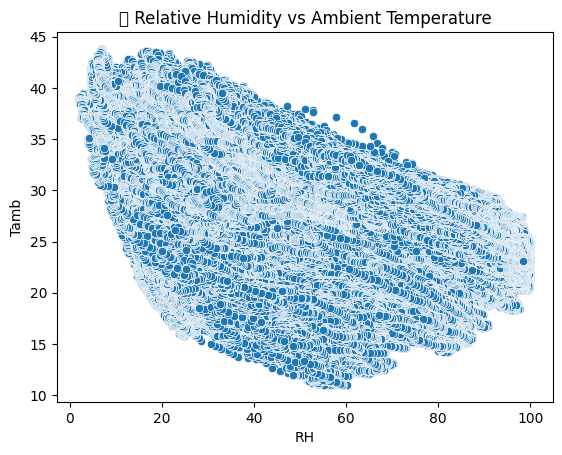

In [ ]:
sns.scatterplot(data=df_clean, x='RH', y='Tamb')
plt.title("🌡️ Relative Humidity vs Ambient Temperature")
plt.show()

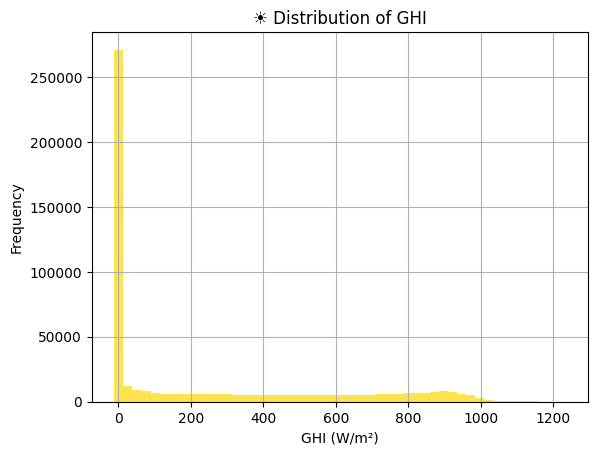

In [ ]:
# 7. Wind & Distribution Analysis
# wind dynamics and variable distributions

# Histogram of GHI
plt.hist(df_clean['GHI'], bins=50, alpha=0.7, color='gold')
plt.title("☀️ Distribution of GHI")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


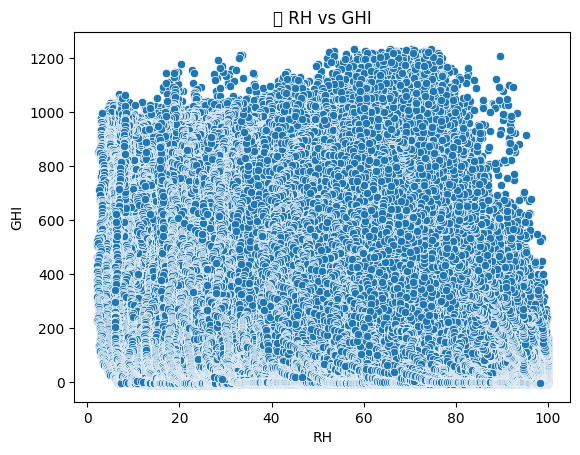

In [ ]:
#  8. Temperature-Humidity Interaction
# Explore how RH may influence temp and solar radiation

sns.scatterplot(data=df_clean, x='RH', y='GHI')
plt.title("🌫️ RH vs GHI")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


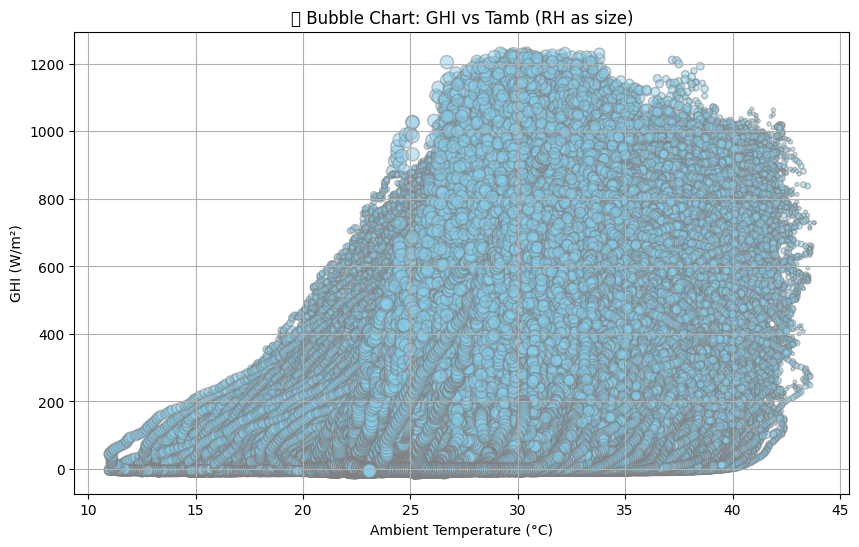

In [ ]:
#  9. Bubble Chart: GHI vs Tamb with RH as size
plt.figure(figsize=(10, 6))
plt.scatter(
    df_clean['Tamb'], df_clean['GHI'],
    s=df_clean['RH'], alpha=0.5, c='skyblue', edgecolors='gray')
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title("🔵 Bubble Chart: GHI vs Tamb (RH as size)")
plt.grid(True)
plt.show()